Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20260120-cytation3-pure-timecourse-gfp-OnePotPURE-Opt-biotek-cdk.txt"
platemap_file = "20260120-OnePotPURE-Opt1-Platemap.csv"

# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Date,Experiment Name,Name,...,SMix Vol (uL),tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,122,B,2,GFP-F-G35,2026-01-20 15:14:38,20260120,OnePot-Optimization1,8 mM Mg,...,3,1.00,0.24,0.50,0.30,NaN,NaN,NaN,1.50,10
1,0 days 00:05:00,B2,190,B,2,GFP-F-G35,2026-01-20 15:19:38,20260120,OnePot-Optimization1,8 mM Mg,...,3,1.00,0.24,0.50,0.30,NaN,NaN,NaN,1.50,10
2,0 days 00:10:00,B2,243,B,2,GFP-F-G35,2026-01-20 15:24:38,20260120,OnePot-Optimization1,8 mM Mg,...,3,1.00,0.24,0.50,0.30,NaN,NaN,NaN,1.50,10
3,0 days 00:15:00,B2,298,B,2,GFP-F-G35,2026-01-20 15:29:38,20260120,OnePot-Optimization1,8 mM Mg,...,3,1.00,0.24,0.50,0.30,NaN,NaN,NaN,1.50,10
4,0 days 00:20:00,B2,357,B,2,GFP-F-G35,2026-01-20 15:34:38,20260120,OnePot-Optimization1,8 mM Mg,...,3,1.00,0.24,0.50,0.30,NaN,NaN,NaN,1.50,10


## Plot Raw Curves

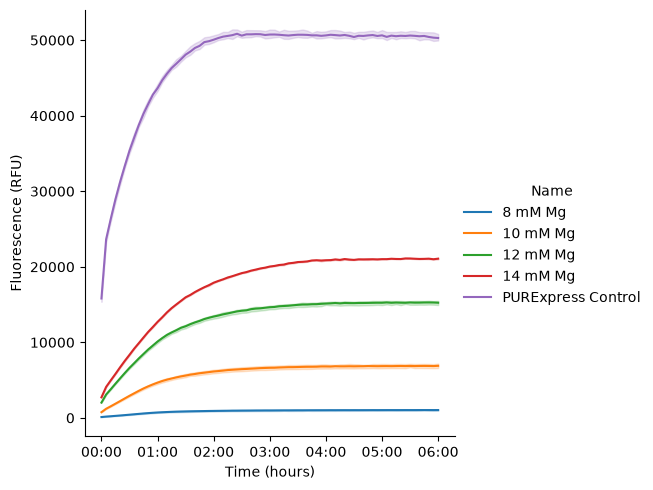

In [4]:
#| label: fig:kinetics-opt1
g = pr.plot_curves(data=data)

## Normalize Data

In [5]:
# No HPTS/fluorescein normalization control present in this platemap's Name column - skipping normalize_data_to_controls, using raw (unnormalized) data

Now replot your curves to see them normalized

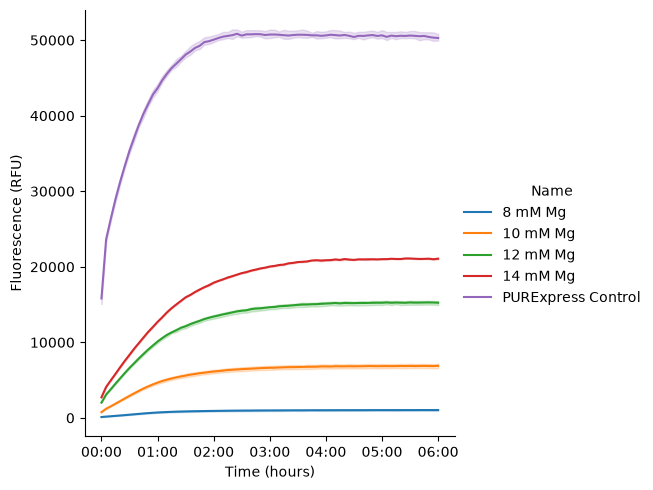

In [6]:
g = pr.plot_curves(data=data)

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [7]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Name'],  # Group by experimental condition
)

kinetics.head()

PROVIDING AVERAGED KINETICS


Velocity                    \
                                        Time     Data      Max   
Name                                                             
10 mM Mg           0 days 00:28:52.653003495  3482.11  3783.83   
12 mM Mg           0 days 00:28:27.569031919  7687.06  7444.71   
14 mM Mg           0 days 00:34:15.744440608 10612.21  8895.96   
8 mM Mg            0 days 00:27:58.684315267   525.39   616.12   
PURExpress Control 0 days 00:09:19.748936394 25414.89 30314.60   

                                           Lag          \
                                          Time    Data   
Name                                                     
10 mM Mg           -1 days +23:33:40.593502651   -2.49   
12 mM Mg           -1 days +23:26:29.983913632   51.15   
14 mM Mg           -1 days +23:22:41.243856634  206.15   
8 mM Mg            -1 days +23:36:43.138068958  -17.47   
PURExpress Control -1 days +23:19:01.605359286 5422.55   

                                Steady State           \
                                        Time     Data   
Name                                                    
10 mM Mg           0 days 01:50:08.731550567  6616.01   
12 mM Mg           0 days 01:59:40.670296384 14605.41   
14 mM Mg           0 days 02:19:38.191897466 20163.19   
8 mM Mg            0 days 01:43:26.563439316   998.23   
PURExpress Control 0 days 01:23:23.118732395 48288.28   

                                                                  Fit       \
                                                               params  R^2   
Name                                                                         
10 mM Mg            [6964.220340905311, 2.1740214182568103, 0.4812... 1.00   
12 mM Mg            [15374.116583665884, 1.9368575835841808, 0.474... 1.00   
14 mM Mg            [21224.41052147962, 1.6765982292757042, 0.5710... 1.00   
8 mM Mg             [1050.7719380773997, 2.3420053921485007, 0.466... 1.00   
PURExpress Control  [50829.77306483261, 2.385645347442464, 0.15548... 0.99   

                           
                    drift  
Name                       
10 mM Mg           135.12  
12 mM Mg           299.17  
14 mM Mg           382.84  
8 mM Mg             22.34  
PURExpress Control  95.26

## Visualize Fits on Individual Wells

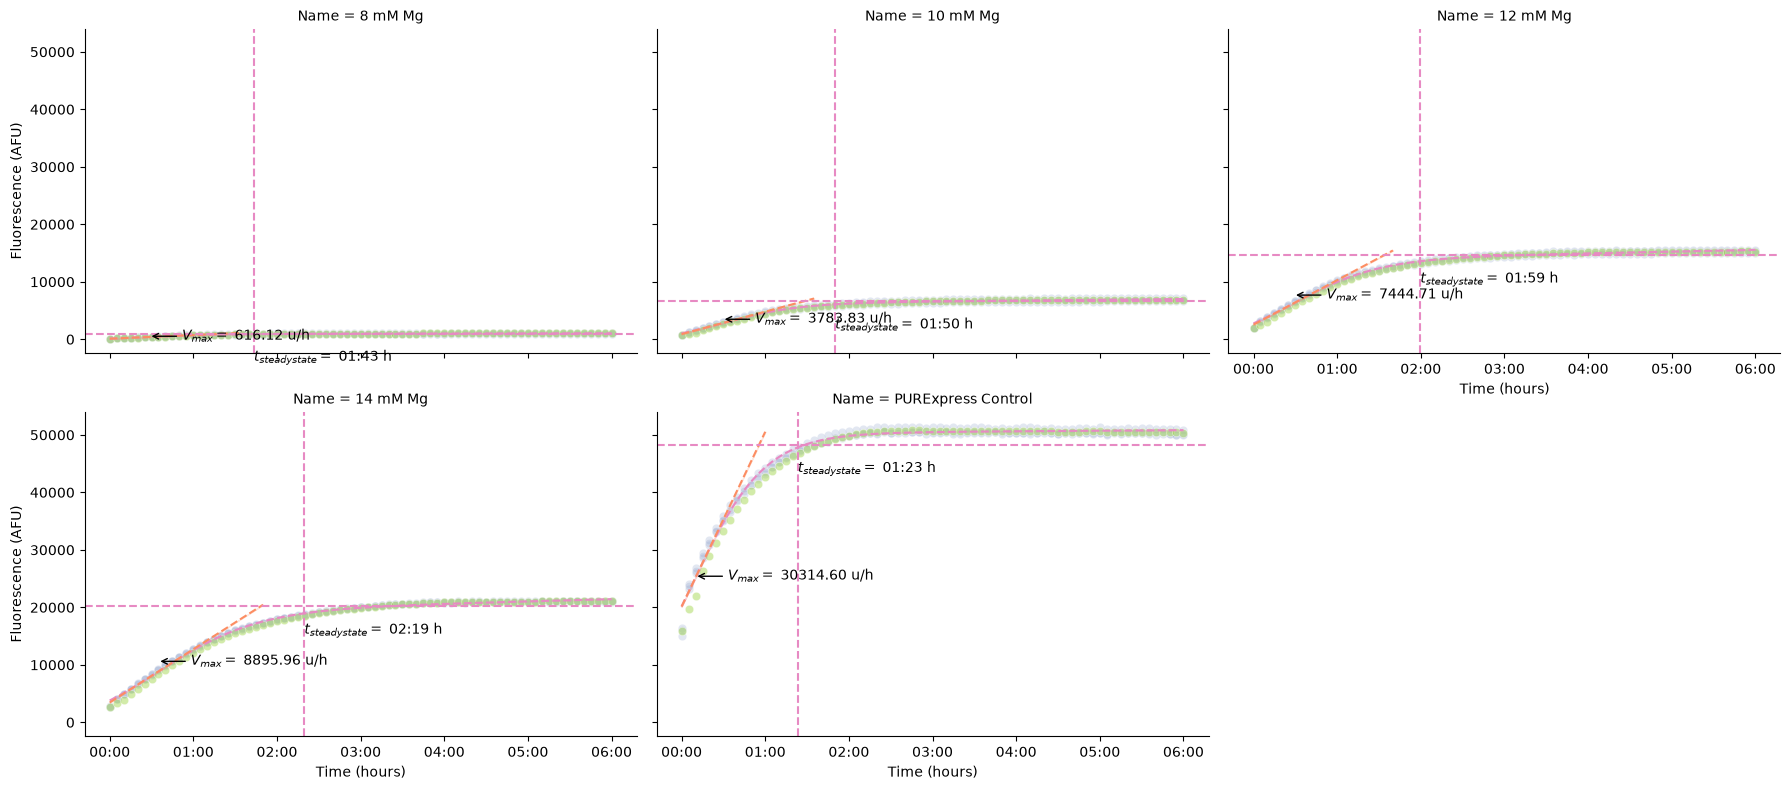

In [8]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics, group_by=["Name"])

## Summary Plots

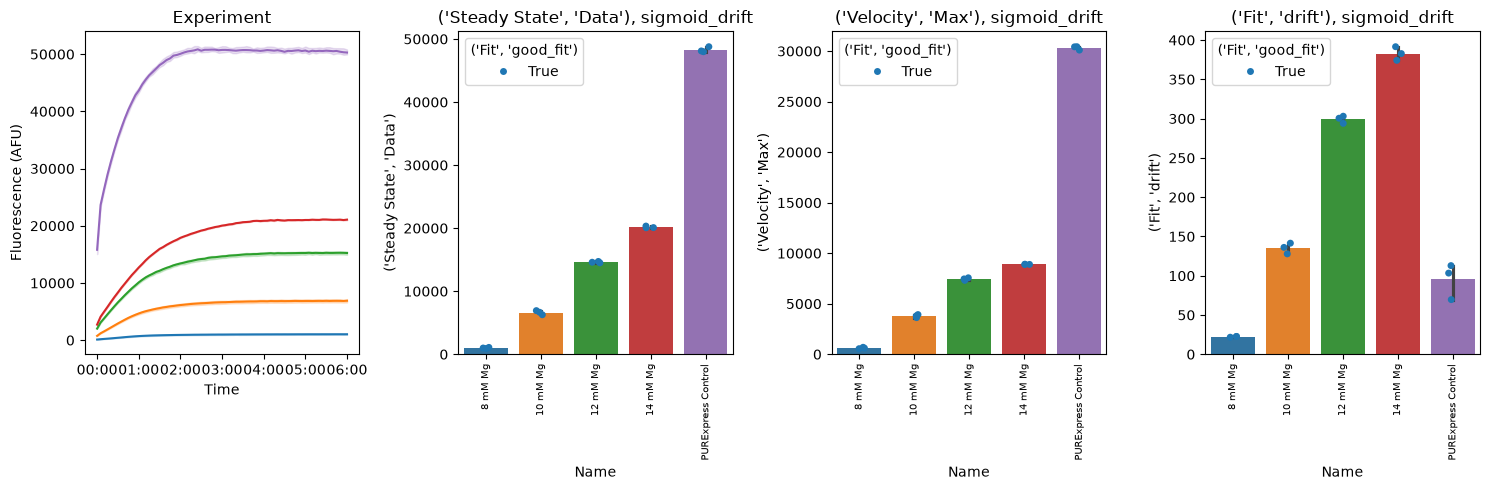

In [9]:

summary_plot = pr.plot_summary(data)

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants